In [1]:
''' For the background of my poster I used an image of the NGC 4676: AKA The Mice 
the link is https://apod.nasa.gov/apod/ap040612.html 

Credit: ACS Science & Engineering Team, NASA
'''

' For the background of my poster I used an image of the NGC 4676: AKA The Mice \nthe link is https://apod.nasa.gov/apod/ap040612.html \n\nCredit: ACS Science & Engineering Team, NASA\n'

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import time as tm
from time import time
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde, ks_2samp, kstest
from hyppo.ksample import Energy, KSample
from hyppo.independence import Hsic
import corner
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import Table, vstack
from glob import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression
import os
from datetime import datetime
from matplotlib.ticker import AutoLocator
from pathlib import Path
from functools import reduce



# Setup and helper functions moved to external module
from equations_file import *

# If you change the external module and want live reload during development, uncomment:
# %load_ext autoreload
# %autoreload 2

In [3]:
with fitsio.FITS(galah_Gaia_fits) as hdul1:
    data_1 = hdul1[1].read()
galah_Gaia_raw = pd.DataFrame(data_1)
galah_Gaia_raw = ensure_native_endian(galah_Gaia_raw)

In [4]:
galah_Gaia = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['flag_mg_fe'] == 0)
                        # & (galah_Gaia_raw['flag_na_fe'] == 0)
                        # & (galah_Gaia_raw['flag_cu_fe'] == 0)
                        & (galah_Gaia_raw['fe_h'] < -0.8)
                        # & (galah_Gaia_raw['fe_h'] < -1.25)
                        # & (galah_Gaia_raw['fe_h'] > -1.8)
                        # & (galah_Gaia_raw['ti_fe'] > 0.25)
                        
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
                        & (galah_Gaia_raw['radial_velocity'].notnull())
                        & (galah_Gaia_raw['ra_gaia'].notnull())
                        & (galah_Gaia_raw['dec_gaia'].notnull())
                        & (galah_Gaia_raw['pmra_gaia'].notnull())
                        & (galah_Gaia_raw['pmdec_gaia'].notnull())
                        & (galah_Gaia_raw['parallax_gaia'] > 0)
                        
    ]

print(f"Number of stars after cuts: {len(galah_Gaia)}")

Number of stars after cuts: 9106


In [5]:
NGC3201_galah = pd.merge( galah_Gaia, Vmans_NGC3201_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC5139_galah = pd.merge( galah_Gaia, Vmans_NGC5139_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC1851_galah = pd.merge( galah_Gaia, Vmans_NGC1851_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')   
NGC0104_galah = pd.merge( galah_Gaia, Vmans_NGC0104_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')

galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)
                                 & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                 & (galah_Gaia_raw['flag_mg_fe'] == 0)
                                 & (galah_Gaia_raw['flag_na_fe'] == 0)
                                 & (galah_Gaia_raw['flag_cu_fe'] == 0)
                                 & ((galah_Gaia_raw['mg_fe'] - galah_Gaia_raw['cu_fe']) - ((1.06923) * galah_Gaia_raw['na_fe']) > 0.40150)
                                 ]

# Kushniruk et al . 2026 https://doi.org/10.1051/0004-6361/202451201
galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

galah_Kushniruk_Thamnos2 = galah_Gaia[(((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_GSE = galah_Gaia[GSE_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_Sequoia = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia_raw['y_fe'] < 0.8)
                            ]

galah_Gaia_Halo = galah_Gaia[(np.sqrt((galah_Gaia['vphi']-230)**2 + (galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2) > 230) # Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                            # & (galah_Gaia_raw['fe_h'] < -1.1)
                            # & (galah_Gaia_raw['fe_h'] > -1.9)
                             ]


/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_80686/656056682.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)



In [6]:
galah_Gaia_else = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['fe_h'] < -0.75)
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_Halo['gaiadr3_source_id']))
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
    ]

In [7]:
Halo_Pradosh_galah_Gaia = galah_Gaia[(galah_Gaia['fe_h'] < -0.8)
                                            & (galah_Gaia['ti_fe'] > 0.25)
                                            & (galah_Gaia['flag_ti_fe'] == 0)
                                            & (galah_Gaia['Lz'] > -1500)
                                            & (galah_Gaia['Lz'] < 1500)
                                            & (galah_Gaia['ecc_gaia'] > 0.5)
                                            & (galah_Gaia['ecc_gaia'] < 0.8)
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

thickdisk_galah_Gaia = galah_Gaia[(galah_Gaia['fe_h'] < -0.8)
                                                 & (galah_Gaia['ti_fe'] > 0.25)
                                                 & (galah_Gaia['Lz'] > 0)
                                                 & (galah_Gaia['ecc_gaia'] < 0.5)
                                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                                                # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                                # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]
print(len(Halo_Pradosh_galah_Gaia))
print(len(thickdisk_galah_Gaia))

galah_Gaia_Halo = Halo_Pradosh_galah_Gaia

1834
2659


In [8]:
print(f'len(NGC3201_galah): {len(NGC3201_galah)}')
print(f'len(NGC5139_galah): {len(NGC5139_galah)}')
print(f'len(NGC1851_galah): {len(NGC1851_galah)}')
print(f'len(NGC0104_galah): {len(NGC0104_galah)}')
print(f'len(galah_Kushniruk_GSE): {len(galah_Kushniruk_GSE)}')
print(f'len(galah_Kushniruk_Thamnos1): {len(galah_Kushniruk_Thamnos1)}')
print(f'len(galah_Kushniruk_Thamnos2): {len(galah_Kushniruk_Thamnos2)}')
print(f'len(galah_Gaia_GSE): {len(galah_Gaia_GSE)}')
print(f'len(galah_Gaia_Sequoia): {len(galah_Gaia_Sequoia)}')
print(f'len(galah_Gaia_Halo): {len(galah_Gaia_Halo)}')
print(f'len(galah_Gaia_else): {len(galah_Gaia_else)}')

len(NGC3201_galah): 0
len(NGC5139_galah): 3
len(NGC1851_galah): 0
len(NGC0104_galah): 37
len(galah_Kushniruk_GSE): 672
len(galah_Kushniruk_Thamnos1): 211
len(galah_Kushniruk_Thamnos2): 19
len(galah_Gaia_GSE): 844
len(galah_Gaia_Sequoia): 126
len(galah_Gaia_Halo): 1834
len(galah_Gaia_else): 156091


In [9]:
galah_Gaia_else_C = "#110C0C"
Sequoia_C = '#d62728'
GSE_C = "#16b823d8"
Halo_C = "#0e35e2"

thamnos_1_C = "#96bd0b"
thamnos_2_C = '#C43DFF'

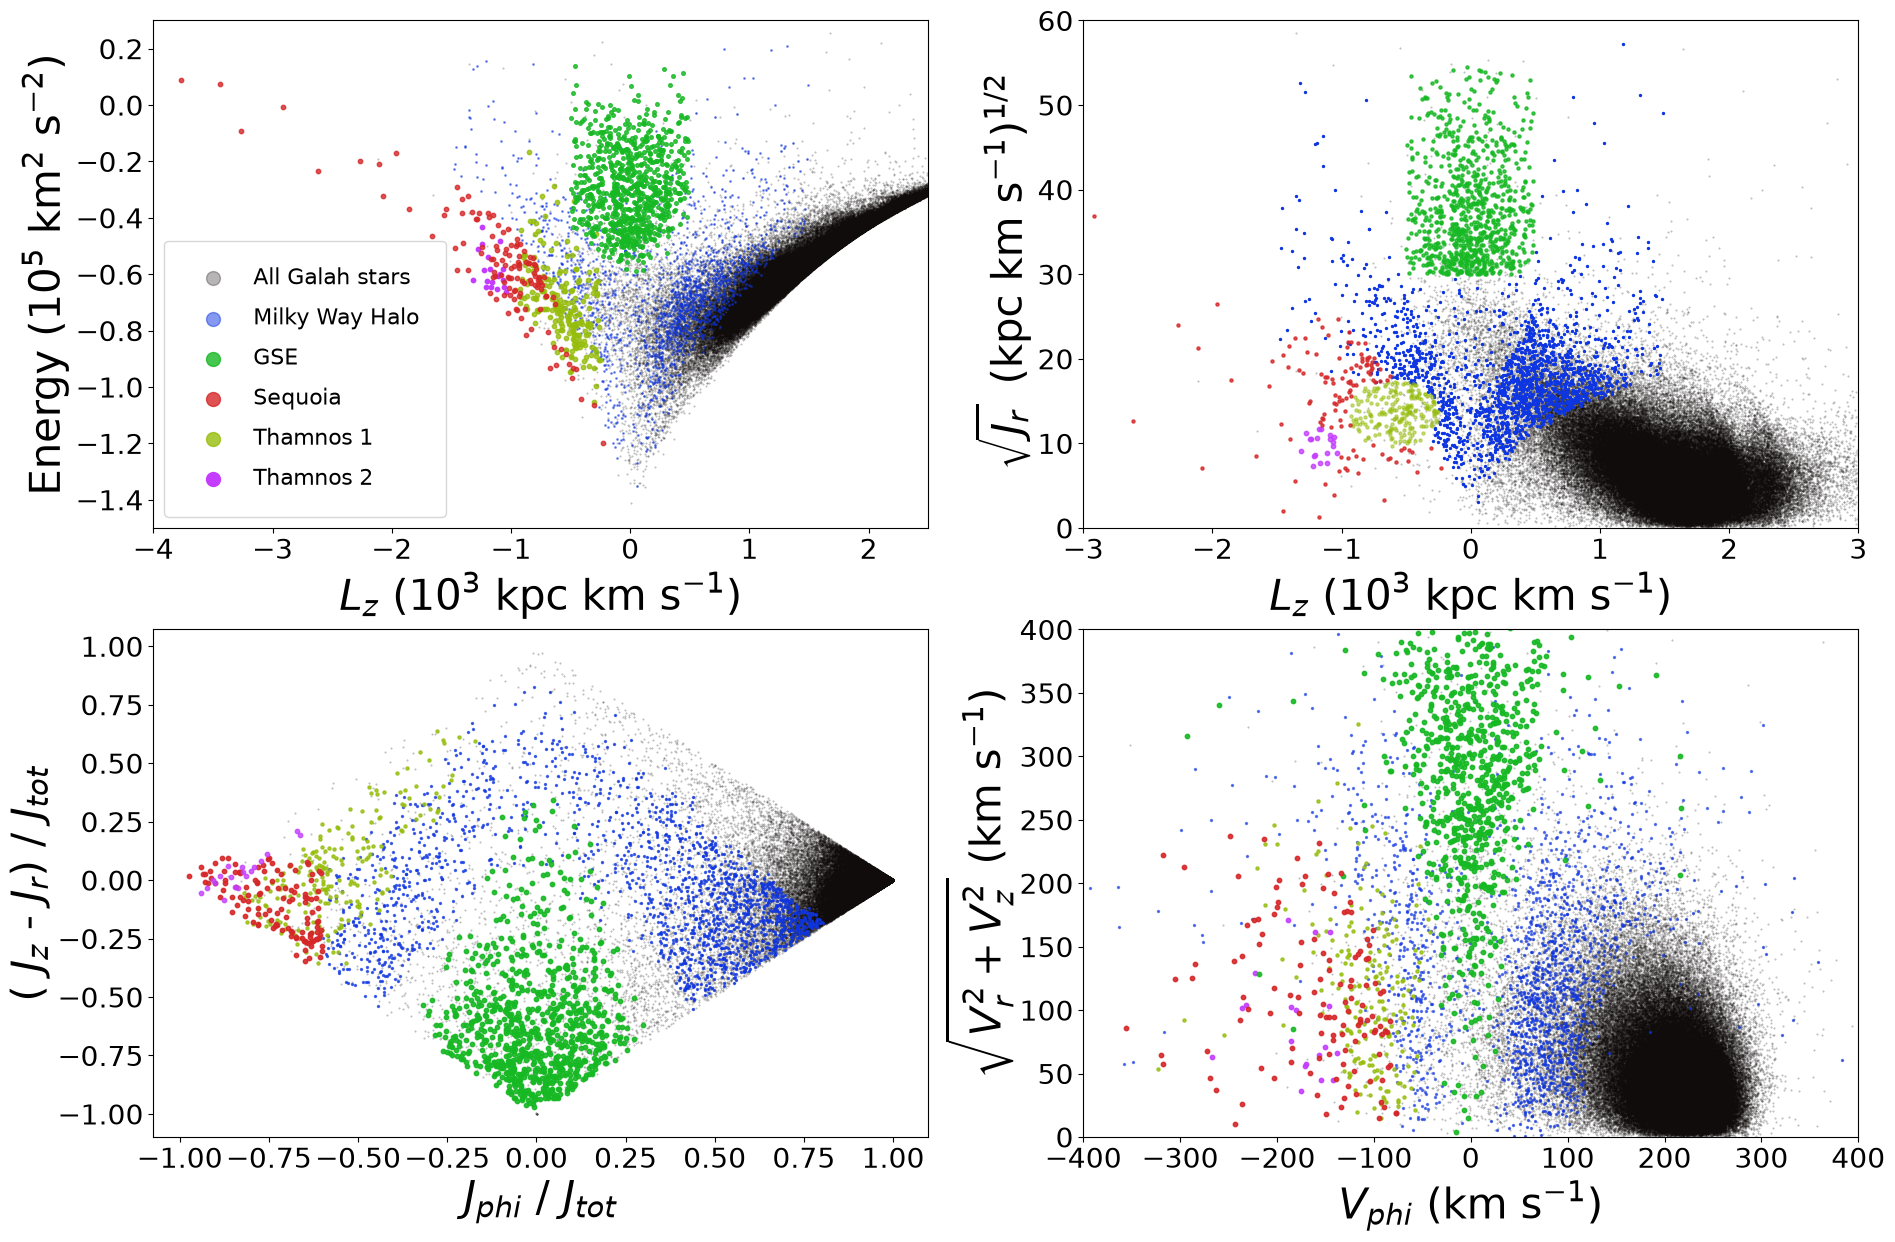

In [ ]:
fig, ax = plt.subplots(2, 2, sharex=False, sharey=False, figsize=(22, 14.5)) # (rows, colums, share y axis and/or share x axis)
# fig.patch.set_alpha(0) # this can make the image transpearent.
fontsize = 30
labelsize = 20

ax[0,0].scatter(galah_Gaia_else['jphi']/1e3, galah_Gaia_else['energy']/1e5, label = 'All Galah stars', s = 0.2, alpha = 0.3, c = galah_Gaia_else_C)
ax[0,0].scatter(galah_Gaia_Halo['jphi']/1e3, galah_Gaia_Halo['energy']/1e5, label = 'Milky Way Halo', s = 1, alpha = 0.5, c = Halo_C)
ax[0,0].scatter(galah_Kushniruk_Thamnos1['jphi']/1e3, galah_Kushniruk_Thamnos1['energy']/1e5, label = 'Thamnos 1', s = 10, alpha = 0.8, c = thamnos_1_C)
ax[0,0].scatter(galah_Kushniruk_Thamnos2['jphi']/1e3, galah_Kushniruk_Thamnos2['energy']/1e5, label = 'Thamnos 2', s = 10, alpha = 1.0, c = thamnos_2_C)
ax[0,0].scatter(galah_Gaia_GSE['jphi']/1e3, galah_Gaia_GSE['energy']/1e5, label = 'GSE', s = 7, alpha = 0.8, c = GSE_C)
ax[0,0].scatter(galah_Gaia_Sequoia['jphi']/1e3, galah_Gaia_Sequoia['energy']/1e5, label = 'Sequoia', s = 10, alpha = 0.8, c = Sequoia_C)
ax[0,0].set_xlim(-4000/1e3, 2500/1e3)
ax[0,0].set_ylim(-150000/1e5,30000/1e5)
ax[0,0].tick_params(axis='x', labelsize = labelsize)
ax[0,0].tick_params(axis='y', labelsize = labelsize)
ax[0,0].set_xlabel(r'$L_z$ ($10^3$ kpc km s$^{-1}$)', fontsize = fontsize)
ax[0,0].set_ylabel(r'Energy ($10^5$ km$^2$ s$^{-2}$)', fontsize = fontsize)

handles, labels = ax[0,0].get_legend_handles_labels()

# Desired legend order
order = [
    labels.index('All Galah stars'),
    labels.index('Milky Way Halo'),
    labels.index('GSE'),
    labels.index('Sequoia'),
    labels.index('Thamnos 1'),
    labels.index('Thamnos 2')
]

leg = ax[0,0].legend(
    [handles[i] for i in order],
    [labels[i] for i in order],
    fontsize=16,
    labelspacing=0.8,
    borderpad=1.2
)

for handle in leg.legend_handles:
    try:
        handle.set_sizes([100])
    except Exception:
        pass
###########################################################################################
ax[0,1].scatter(galah_Gaia_else['jphi']/1e3, np.sqrt(galah_Gaia_else['jr']), label = 'All Galah stars', s = 0.2, alpha = 0.3, c = galah_Gaia_else_C)
ax[0,1].scatter(galah_Gaia_Halo['jphi']/1e3, np.sqrt(galah_Gaia_Halo['jr']), label = 'Halo', s = 2, alpha = 1.0, c = Halo_C)
ax[0,1].scatter(galah_Kushniruk_Thamnos1['jphi']/1e3, np.sqrt(galah_Kushniruk_Thamnos1['jr']), label = 'Thamnos 1', s = 5, alpha = 0.5, c = thamnos_1_C)
ax[0,1].scatter(galah_Kushniruk_Thamnos2['jphi']/1e3, np.sqrt(galah_Kushniruk_Thamnos2['jr']), label = 'Thamnos 2', s = 10, alpha = 0.8, c = thamnos_2_C)
ax[0,1].scatter(galah_Gaia_GSE['jphi']/1e3, np.sqrt(galah_Gaia_GSE['jr']), label = 'GSE', s = 5, alpha = 0.8, c = GSE_C)
ax[0,1].scatter(galah_Gaia_Sequoia['jphi']/1e3, np.sqrt(galah_Gaia_Sequoia['jr']), label = 'Sequoia', s = 5, alpha = 0.8, c = Sequoia_C)
ax[0,1].set_xlim(-3000/1e3, 3000/1e3)
ax[0,1].set_ylim(0,60)
ax[0,1].tick_params(axis='x', labelsize = labelsize)
ax[0,1].tick_params(axis='y', labelsize = labelsize)
ax[0,1].set_xlabel(r'$L_z$ ($10^3$ kpc km s$^{-1}$)', fontsize = fontsize)
ax[0,1].set_ylabel(r'$\,\sqrt{J_r}\,$ (kpc km s$^{-1}$)$^{1/2}$', fontsize = fontsize);
###########################################################################################
ax[1,0].scatter( galah_Gaia_else['jphi']/ galah_Gaia_else['jtot'], (galah_Gaia_else['jz'] - galah_Gaia_else['jr'])/galah_Gaia_else['jtot'], label = 'All Galah stars', s = 0.2, c = galah_Gaia_else_C, alpha = 0.3)
ax[1,0].scatter( galah_Gaia_Halo['jphi']/ galah_Gaia_Halo['jtot'], (galah_Gaia_Halo['jz'] - galah_Gaia_Halo['jr'])/galah_Gaia_Halo['jtot'], label = 'Milky Way Halo', s = 2, c = Halo_C, alpha = 0.7)
ax[1,0].scatter( galah_Kushniruk_Thamnos1['jphi']/ galah_Kushniruk_Thamnos1['jtot'], (galah_Kushniruk_Thamnos1['jz'] - galah_Kushniruk_Thamnos1['jr'])/galah_Kushniruk_Thamnos1['jtot'], label = 'Thamnos 1', c = thamnos_1_C, s = 5, alpha = 0.8)
ax[1,0].scatter( galah_Gaia_GSE['jphi']/ galah_Gaia_GSE['jtot'], (galah_Gaia_GSE['jz'] - galah_Gaia_GSE['jr'])/galah_Gaia_GSE['jtot'], label = 'GSE', c = GSE_C, s = 10, alpha  = 0.9)
ax[1,0].scatter( galah_Gaia_Sequoia['jphi']/ galah_Gaia_Sequoia['jtot'], (galah_Gaia_Sequoia['jz'] - galah_Gaia_Sequoia['jr'])/galah_Gaia_Sequoia['jtot'], label = 'Sequoia', c = Sequoia_C, s = 10, alpha = 0.9)
ax[1,0].scatter( galah_Kushniruk_Thamnos2['jphi']/ galah_Kushniruk_Thamnos2['jtot'], (galah_Kushniruk_Thamnos2['jz'] - galah_Kushniruk_Thamnos2['jr'])/galah_Kushniruk_Thamnos2['jtot'], label = 'Thamnos 2', c = thamnos_2_C, s = 10, alpha = 0.8)
ax[1,0].set_xlabel(r'$J_{phi}$ / $J_{tot}$', fontsize = fontsize)
ax[1,0].set_ylabel(r'( $J_z$ - $J_r$) / $J_{tot}$', fontsize = fontsize)
ax[1,0].tick_params(axis='x', labelsize = labelsize)
ax[1,0].tick_params(axis='y', labelsize = labelsize)
############################################################################################
ax[1,1].scatter(galah_Gaia_else['vphi'], np.sqrt((galah_Gaia_else['vr'])**2 + (galah_Gaia_else['vz'])**2), label = 'All Galah stars', s = 0.2, alpha = 0.3, c = galah_Gaia_else_C)
ax[1,1].scatter(galah_Gaia_Halo['vphi'], np.sqrt((galah_Gaia_Halo['vr'])**2 + (galah_Gaia_Halo['vz'])**2), label = 'Halo', s = 2, alpha = 0.6, c = Halo_C)
ax[1,1].scatter(galah_Kushniruk_Thamnos1['vphi'], np.sqrt((galah_Kushniruk_Thamnos1['vr'])**2 + (galah_Kushniruk_Thamnos1['vz'])**2), label = 'Thamnos1', s = 5, alpha = 0.8, c = thamnos_1_C)
ax[1,1].scatter(galah_Kushniruk_Thamnos2['vphi'], np.sqrt((galah_Kushniruk_Thamnos2['vr'])**2 + (galah_Kushniruk_Thamnos2['vz'])**2), label = 'Thamnos2', s = 10, alpha = 0.9, c = thamnos_2_C)
ax[1,1].scatter(galah_Gaia_GSE['vphi'], np.sqrt((galah_Gaia_GSE['vr'])**2 + (galah_Gaia_GSE['vz'])**2), label = 'GSE', s = 10, alpha = 0.9, c = GSE_C)
ax[1,1].scatter(galah_Gaia_Sequoia['vphi'], np.sqrt((galah_Gaia_Sequoia['vr'])**2 + (galah_Gaia_Sequoia['vz'])**2), label = 'Sequoia', s = 10, alpha = 0.9, c = Sequoia_C)
ax[1,1].set_xlim(-400, 400)
ax[1,1].set_ylim(0,400)
ax[1,1].tick_params(axis='x', labelsize = labelsize)
ax[1,1].tick_params(axis='y', labelsize = labelsize)
ax[1,1].set_xlabel(r'$V_{phi}$ (km s$^{-1}$)', fontsize = fontsize)
ax[1,1].set_ylabel(r'$\sqrt{V_r^2 + V_z^2}$ (km s$^{-1}$)', fontsize = fontsize)

# plt.savefig('Kinematics.png', dpi = 1200, bbox_inches='tight')




Means: [-1.59809444]
Standard deviations: [0.35133044]
Weights: [1.]
Maximum PDF value: 1.1355185777132792
Means: [-1.33941006]
Standard deviations: [0.32917864]
Weights: [1.]
Maximum PDF value: 1.2119299419641258


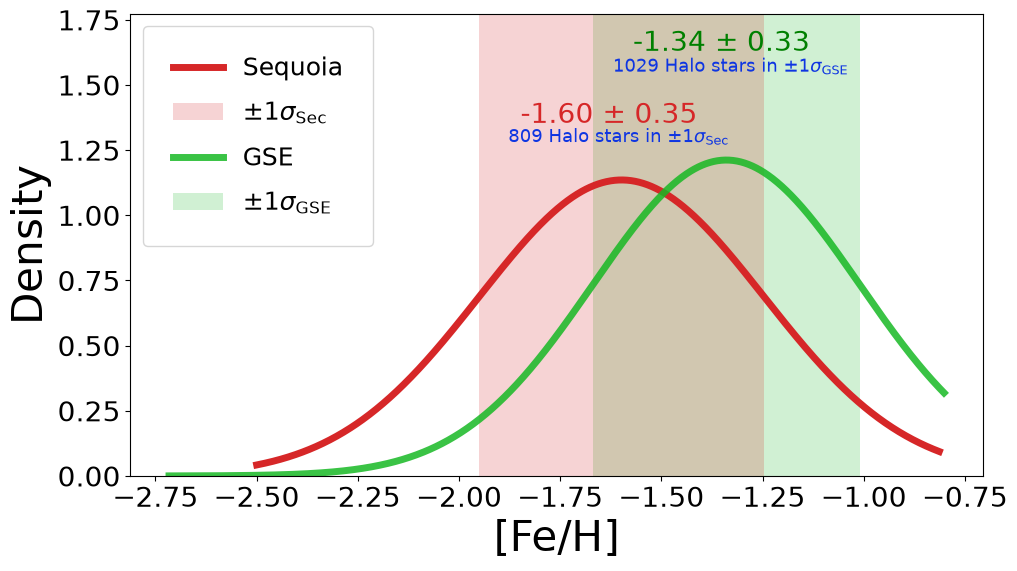

In [ ]:
plt.figure(figsize=(11, 6)) #(length, height)
elm_ratio = 'fe_h'
n_components = 1
shift_right = 0.32
fontsize = 20

elm_lable = elm_ratio
elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])

sec_mean = np.mean(galah_Gaia_Sequoia[elm_ratio])
one_sig_sec = np.std(galah_Gaia_Sequoia[elm_ratio])
pl_1sig_sec = sec_mean + one_sig_sec
min_1sig_sec = sec_mean - one_sig_sec
plot_gmm(galah_Gaia_Sequoia[elm_ratio].dropna(), f'Sequoia', n_components = n_components, color=Sequoia_C, maximum_peak=True, plot_compents = True, fontsize = fontsize, 
        #  shift_right=shift_right, shift_up= 0.91)
        shift_right=-0.25, shift_up= 0.2, linewidth_main = 5)
plt.axvspan(min_1sig_sec, pl_1sig_sec, facecolor=Sequoia_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{Sec}}$")

galah_Gaia_Halo_sec_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_sec) & (galah_Gaia_Halo[elm_ratio] > min_1sig_sec))
plt.text(sec_mean -0.28, 1.28, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_sec_1sig])} Halo stars in 'r"$\pm 1 \sigma_{\mathrm{Sec}}$", c = Halo_C, fontsize = 13.0)



gse_mean = np.mean(galah_Gaia_GSE[elm_ratio])
one_sig_gse = np.std(galah_Gaia_GSE[elm_ratio])
pl_1sig_gse = gse_mean + one_sig_gse
min_1sig_gse = gse_mean - one_sig_gse
plot_gmm(galah_Gaia_GSE[elm_ratio].dropna(), f'GSE', n_components = n_components, color=GSE_C, maximum_peak=True, fontsize = fontsize, 
        #  shift_right=shift_right, shift_up= 0.81)
        shift_right=-0.23, shift_up= 0.4, linewidth_main = 5)
plt.axvspan(min_1sig_gse, pl_1sig_gse, facecolor=GSE_C, alpha=0.2, label = r"$\pm 1\sigma_{\mathrm{GSE}}$", zorder=0,)

galah_Gaia_Halo_gse_1sig = ((galah_Gaia_Halo[elm_ratio] < pl_1sig_gse) & (galah_Gaia_Halo[elm_ratio] > min_1sig_gse))
plt.text(gse_mean -0.28, 1.55, f'{len(galah_Gaia_Halo[galah_Gaia_Halo_gse_1sig])} Halo stars in 'r"$\pm 1\sigma_{\mathrm{GSE}}$", c = Halo_C, fontsize = 13.0)


# plot_gmm(galah_Gaia_Halo[elm_ratio].dropna(), f'Halo', n_components = n_components, color='blue', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.71)

# plt.hist(galah_Gaia_Sequoia[elm_ratio].dropna(), bins=30, color = 'r', alpha=0.5, label='Sequoia', density=True, histtype='step')
# plt.hist(galah_Gaia_GSE[elm_ratio].dropna(), bins=30, color = 'g', density=True, histtype='step')
# plt.hist(galah_Gaia_Halo[elm_ratio].dropna(), bins=30, color = Halo_C, alpha=0.5, label='Halo', density=True, histtype='step', linewidth = 5)

# galah_Kushniruk_Thamnos1_mask = (galah_Kushniruk_Thamnos1['fe_h'] <-0.75)
# plt.hist(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), bins=30, color = 'darkseagreen', alpha=0.5, label='Thamnos', density=True, histtype='step')
# plot_gmm(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), f'Halo', n_components = 3, color='darkseagreen', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.61)

leg = plt.legend(fontsize=18, labelspacing=0.8, borderpad=1.2, loc = 'upper left')
# for handle in leg.legend_handles:
    # handle.set_sizes([100])

peak_height  = max(plt.gca().get_ylim())
plt.ylim(0, peak_height + 0.5)
plt.tick_params(axis='x', labelsize=20)
plt.tick_params(axis='y', labelsize=20)
plt.xlabel(f'[{elm_lable_display}]', fontsize = 30)
plt.ylabel('Density', fontsize = 30)


# plt.savefig('Sec and GSE metalicity.png', dpi = 2400, bbox_inches='tight')


In [169]:

element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = [ 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']  # now I wonder if I could use sm_fe, o_fe, 
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'na', 'nd']                                                             # and/or la_fe
element_list_partial_small_galah_11 = ['y', 'ba', 'nd', 'eu']                                                                                 # also la and sm would bring me to (50, 45, or 44combined)/65 sequoia stars otherwise
element_list_partial_small_galah_16 =  ["na", "mg", "ca", "ti", "cr" ,"mn", "ni", 'cu', "y", "ba", "nd"]


ASA_Plots_ratios = ['fe', 'si', 'ca', 'ti', 'mn', 'ni', 'y', 'nd']
S_VS_G_best_elms = ['na', 'mn', 'ti', 'cr']

# element_list = S_VS_G_best_elms
element_list = element_list_partial_small_galah_7_5


galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
# galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
# galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(Halo_Pradosh_galah_Gaia, element_list)
Halo_Pradosh_galah_Gaia_new_ratios = Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_else, element_list)
galah_Gaia_else_new_ratios = galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_raw_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_raw, element_list)
galah_Gaia_raw_new_ratios = galah_Gaia_raw_new_ratios_catolog_ratiolist_ratioerrorlist[0]


'----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------'

# element_list_full_galah_almost = ["n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", "y", "zr", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
element_list_full_galah_almost = ['fe', 'c', "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", "co", "ni", "cu", "zn", "y", "zr", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.


element_list_nessessary_flags = element_list_full_galah_almost

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia, element_list_nessessary_flags)
galah_Gaia_new_ratios_nessessary_flags_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]
galah_Gaia_new_ratios_nessessary_flags = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]


galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_Sequoia, element_list_nessessary_flags)
galah_Gaia_Sequoia_new_ratios_nessessary_flags = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]
 
galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_GSE, element_list_nessessary_flags)
galah_Gaia_GSE_new_ratios_nessessary_flags = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(galah_Gaia_Halo, element_list_nessessary_flags)
galah_Gaia_Halo_new_ratios_nessessary_flags = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah_only_flag_nessessary_columns(Halo_Pradosh_galah_Gaia, element_list_nessessary_flags)
Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags = Halo_Pradosh_galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0]



/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:720: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_error_label] = np.sqrt((data_set_flagged[err_col_numerator])**2 + (data_set_flagged[err_col_denominator])**2)

/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:719: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_label] = data_set_flagged[col_name_for_numerator] - data_set_flagged[col_name_for_denominat

In [170]:
print(f'len(galah_Gaia_Sequoia_new_ratios): {len(galah_Gaia_Sequoia_new_ratios)}')
print(f'len(galah_Gaia_GSE_new_ratios): {len(galah_Gaia_GSE_new_ratios)}')
print(f'len(galah_Gaia_Halo_new_ratios): {len(galah_Gaia_Halo_new_ratios)}')
print(f'len(galah_Gaia_else_new_ratios): {len(galah_Gaia_else_new_ratios)}')


len(galah_Gaia_Sequoia_new_ratios): 64
len(galah_Gaia_GSE_new_ratios): 503
len(galah_Gaia_Halo_new_ratios): 1147
len(galah_Gaia_else_new_ratios): 136249


Sequoia vs Halo:
statistic: 0.05100585568543277, p-value: 3.894022953171698e-08,  for Ni/Na vs Cu/Ca

Sequoia vs GSE:
statistic: 0.0890647050317349, p-value: 5.627365780096056e-11,  for Cr/Ca vs Nd/Y

GSE vs Halo:
statistic: 0.16867698830978461, p-value: 4.705671272129016e-90,  for Mn/Na vs Nd/Y



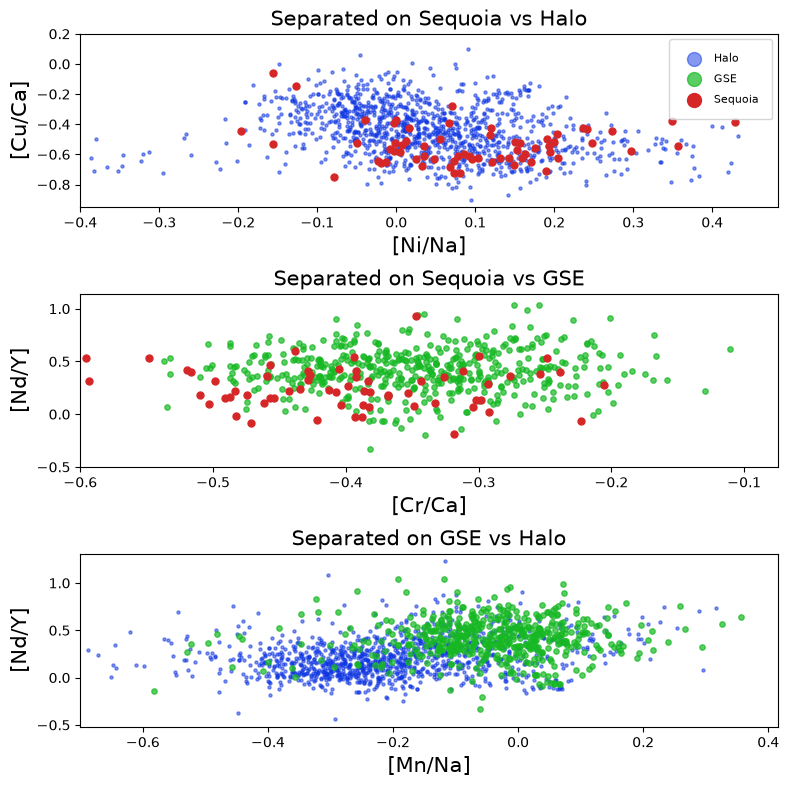

In [171]:
# ratio_combination_list = [['ca_v', 'na_sc'],['cr_sc', 'nd_y'],['mn_na', 'nd_y']] # S_vs_H, S_vs_G, G_vs_H # this was using 7_5 abundances
ratio_combination_list = [['ni_na', 'cu_ca'],['cr_ca', 'nd_y'],['mn_na', 'nd_y']] # S_vs_H, S_vs_G, G_vs_H 
fig, ax = plt.subplots(3, 1, sharex=False, sharey=False, figsize=(9, 9)) # (rows, colums, share y axis and/or share x axis)
plt.subplots_adjust(hspace=0.5)
fontsize = 15
labelsize = 10

for i in range(len(ratio_combination_list)):
    elm_ratio1 = ratio_combination_list[i][0]
    elm_ratio2 = ratio_combination_list[i][1]

    elm_lable_x = elm_ratio1
    elm_lable_y = elm_ratio2

    # Create display labels: replace '_' with '/' and capitalize first letter of each segment
    elm_lable_x_display = '/'.join([seg.capitalize() for seg in elm_lable_x.replace('_', '/').split('/')])
    elm_lable_y_display = '/'.join([seg.capitalize() for seg in elm_lable_y.replace('_', '/').split('/')])

    if i == 0:
        separation_on = 'Sequoia vs Halo'
        X = galah_Gaia_Sequoia_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
        Y = galah_Gaia_Halo_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()

        ax[i].scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)
        # ax[i].scatter(Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio1], Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)

        ax[i].scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = Sequoia_C, label = 'Sequoia', s = 25)
        ax[i].scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = GSE_C, label = 'GSE', s = 0, alpha = 0.7)
        
        handles, labels = ax[i].get_legend_handles_labels()

        # Desired legend order
        order = [
            labels.index('Halo'),
            labels.index('GSE'),
            labels.index('Sequoia'),
        ]

        leg = ax[i].legend(
            [handles[p] for p in order],
            [labels[p] for p in order],
            fontsize=8,
            labelspacing=0.8,
            borderpad=1.2,
            loc="upper right",
        )

        for handle in leg.legend_handles:
            try:
                handle.set_sizes([100])
            except Exception:
                pass
        
        ax[i].set_xlim(-0.4,None)
        ax[i].set_ylim(None, 0.2)
        
    elif i == 1:
        separation_on = 'Sequoia vs GSE'
        X = galah_Gaia_Sequoia_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
        Y = galah_Gaia_GSE_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
        ax[i].scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = GSE_C, label = 'GSE', s = 15, alpha = 0.7)
        ax[i].scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = Sequoia_C, label = 'Sequoia', s = 25)

        ax[i].set_xlim(-0.6,None)
        ax[i].set_ylim(-0.5, None)
        
    elif i == 2:
        separation_on = 'GSE vs Halo'
        X = galah_Gaia_GSE_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
        Y = galah_Gaia_Halo_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
        
        ax[i].scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)
        # ax[i].scatter(Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio1], Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)
        ax[i].scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = GSE_C, label = 'GSE', s = 15, alpha = 0.7)

        ax[i].set_xlim(-0.7,None)
        ax[i].set_ylim(None, None)

    print(f'{separation_on}:')
    statistic, p_value = Energy().test(X, Y)
    print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x_display} vs {elm_lable_y_display}')
    print("")
    

    # plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
    #             c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
    #             # c = 'k',
    #             label = 'All Galah', s = 1, alpha = 1)


    ax[i].set_title(f'Separated on {separation_on}', fontsize = fontsize)
    ax[i].set_xlabel(F'[{elm_lable_x_display}]', fontsize = fontsize)
    ax[i].set_ylabel(F'[{elm_lable_y_display}]', fontsize = fontsize)
    ax[i].tick_params(axis='x', labelsize = labelsize)
    ax[i].tick_params(axis='y', labelsize = labelsize)
    
# plt.savefig('Energ_sep_elms_16.png', dpi = 2400, bbox_inches='tight')



Sequoia vs Halo:
statistic: 0.05100585568543277, p-value: 3.894022953171698e-08,  for Ni/Na vs Cu/Ca



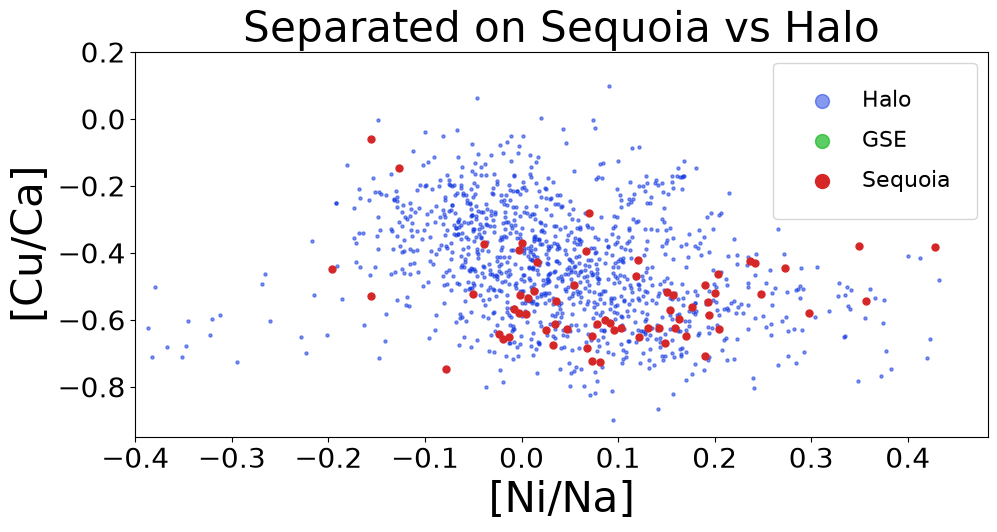

In [172]:
plt.figure(figsize=(11, 5)) #(length, height)
fontsize = 30
labelsize = 20

elm_ratio = ['ni_na', 'cu_ca']

elm_ratio1 = elm_ratio[0]
elm_ratio2 = elm_ratio[1]

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2

# Create display labels: replace '_' with '/' and capitalize first letter of each segment
elm_lable_x_display = '/'.join([seg.capitalize() for seg in elm_lable_x.replace('_', '/').split('/')])
elm_lable_y_display = '/'.join([seg.capitalize() for seg in elm_lable_y.replace('_', '/').split('/')])

separation_on = 'Sequoia vs Halo'
X = galah_Gaia_Sequoia_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
Y = galah_Gaia_Halo_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()

plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)
# plt.scatter(Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio1], Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)

plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = Sequoia_C, label = 'Sequoia', s = 25)
plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = GSE_C, label = 'GSE', s = 0, alpha = 0.7)

handles, labels = plt.gca().get_legend_handles_labels()

# Desired legend order
order = [
    labels.index('Halo'),
    labels.index('GSE'),
    labels.index('Sequoia'),
]

leg = plt.legend(
    [handles[p] for p in order],
    [labels[p] for p in order],
    fontsize=16,
    labelspacing=0.8,
    borderpad=1.2,
    loc="upper right",
)

for handle in leg.legend_handles:
    try:
        handle.set_sizes([100])
    except Exception:
        pass

plt.xlim(-0.4,None)
plt.ylim(None, 0.2)

print(f'{separation_on}:')
statistic, p_value = Energy().test(X, Y)
print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x_display} vs {elm_lable_y_display}')
print("")


# plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
#             c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
#             # c = 'k',
#             label = 'All Galah', s = 1, alpha = 1)


plt.title(f'Separated on {separation_on}', fontsize = fontsize)
plt.xlabel(F'[{elm_lable_x_display}]', fontsize = fontsize)
plt.ylabel(F'[{elm_lable_y_display}]', fontsize = fontsize)
plt.tick_params(axis='x', labelsize = labelsize)
plt.tick_params(axis='y', labelsize = labelsize)

# plt.savefig('Energ_sep_elms_16_S_VS_H.png', dpi = 2400, bbox_inches='tight')


Sequoia vs GSE:
statistic: 0.0890647050317349, p-value: 5.627365780096056e-11,  for Cr/Ca vs Nd/Y



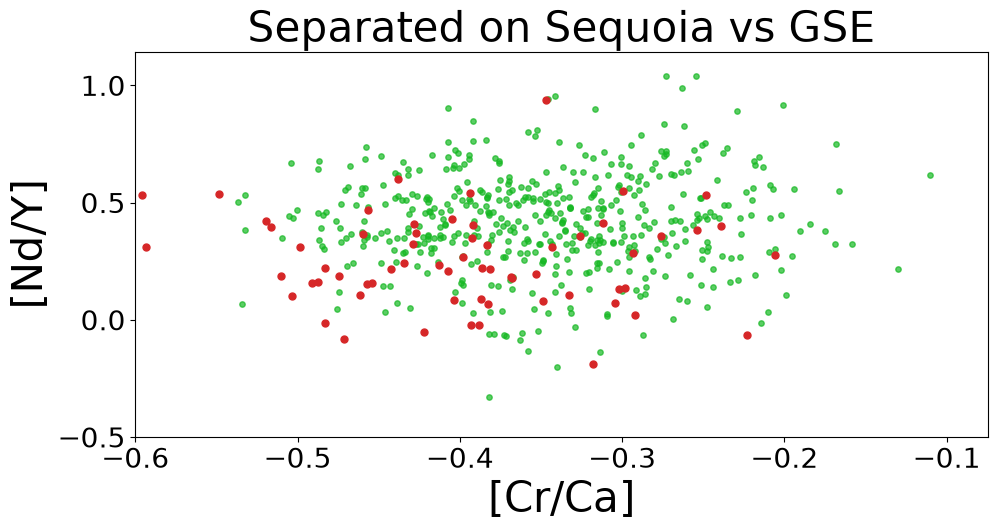

In [173]:
plt.figure(figsize=(11, 5)) #(length, height)
fontsize = 30
labelsize = 20

elm_ratio = ['cr_ca', 'nd_y']

elm_ratio1 = elm_ratio[0]
elm_ratio2 = elm_ratio[1]

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2

# Create display labels: replace '_' with '/' and capitalize first letter of each segment
elm_lable_x_display = '/'.join([seg.capitalize() for seg in elm_lable_x.replace('_', '/').split('/')])
elm_lable_y_display = '/'.join([seg.capitalize() for seg in elm_lable_y.replace('_', '/').split('/')])

separation_on = 'Sequoia vs GSE'
X = galah_Gaia_Sequoia_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
Y = galah_Gaia_GSE_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = GSE_C, label = 'GSE', s = 15, alpha = 0.7)
plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = Sequoia_C, label = 'Sequoia', s = 25)

plt.xlim(-0.6,None)
plt.ylim(-0.5, None)

print(f'{separation_on}:')
statistic, p_value = Energy().test(X, Y)
print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x_display} vs {elm_lable_y_display}')
print("")


# plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
#             c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
#             # c = 'k',
#             label = 'All Galah', s = 1, alpha = 1)


plt.title(f'Separated on {separation_on}', fontsize = fontsize)
plt.xlabel(F'[{elm_lable_x_display}]', fontsize = fontsize)
plt.ylabel(F'[{elm_lable_y_display}]', fontsize = fontsize)
plt.tick_params(axis='x', labelsize = labelsize)
plt.tick_params(axis='y', labelsize = labelsize)

# plt.savefig('Energ_sep_elms_16_S_VS_G.png', dpi = 2400, bbox_inches='tight')


GSE vs Halo:
statistic: 0.16867698830978461, p-value: 4.705671272129016e-90,  for Mn/Na vs Nd/Y



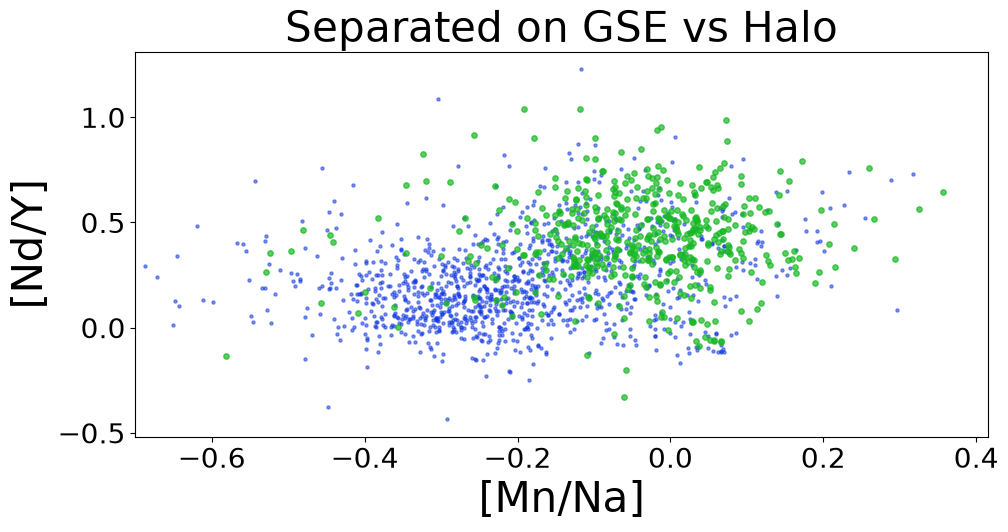

In [174]:
plt.figure(figsize=(11, 5)) #(length, height)
fontsize = 30
labelsize = 20

elm_ratio = ['mn_na', 'nd_y']

elm_ratio1 = elm_ratio[0]
elm_ratio2 = elm_ratio[1]

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2

# Create display labels: replace '_' with '/' and capitalize first letter of each segment
elm_lable_x_display = '/'.join([seg.capitalize() for seg in elm_lable_x.replace('_', '/').split('/')])
elm_lable_y_display = '/'.join([seg.capitalize() for seg in elm_lable_y.replace('_', '/').split('/')])

separation_on = 'GSE vs Halo'
X = galah_Gaia_GSE_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
Y = galah_Gaia_Halo_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()

plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)
# ax[i].scatter(Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio1], Halo_Pradosh_galah_Gaia_new_ratios[elm_ratio2], c = Halo_C, label = 'Halo', s = 5, alpha = 0.5)
plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = GSE_C, label = 'GSE', s = 15, alpha = 0.7)

plt.xlim(-0.7,None)
plt.ylim(None, None)


print(f'{separation_on}:')
statistic, p_value = Energy().test(X, Y)
print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x_display} vs {elm_lable_y_display}')
print("")


# plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
#             c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
#             # c = 'k',
#             label = 'All Galah', s = 1, alpha = 1)


plt.title(f'Separated on {separation_on}', fontsize = fontsize)
plt.xlabel(F'[{elm_lable_x_display}]', fontsize = fontsize)
plt.ylabel(F'[{elm_lable_y_display}]', fontsize = fontsize)
plt.tick_params(axis='x', labelsize = labelsize)
plt.tick_params(axis='y', labelsize = labelsize)

# plt.savefig('Energ_sep_elms_16_H_VS_G.png', dpi = 2400, bbox_inches='tight')


In [175]:
element_list_full_galah = ['li', 'c', "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", 'fe', "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.

df = galah_Gaia_Sequoia
# df = galah_Gaia_GSE
# df = Halo_Pradosh_galah_Gaia

total_num = len(df)
print(f'only fe_h flag: {total_num}')

high_percent = pd.DataFrame(columns=['x_fe', 'mean_x_fe', 'std_x_fe', 'median_e_x_fe', 'num_remaining', 'percent_remaining'])
for i in range(len(element_list_full_galah)):
    print('')
    copy_df = df.copy()
    
    if element_list_full_galah[i] == 'fe':

        X_Fe = 'fe_h'
        X_FE_flag_mask = (copy_df['flag_fe_h'] == 0)
        num = len(copy_df[X_FE_flag_mask])
        median_err_X_FE = np.median(copy_df[X_FE_flag_mask]['e_fe_h'])
    
    elif element_list_full_galah[i] == 'li':
        X_Fe = 'nn_li_fe'
        X_FE_flag_mask = (copy_df['nn_flag_li_fe'] == 0)
        num = len(copy_df[X_FE_flag_mask])
        median_err_X_FE = np.median(copy_df[X_FE_flag_mask]['nn_e_li_fe'])

    
    else:
        print('')
        copy_df = df.copy()
        X_Fe = f'{element_list_full_galah[i]}_fe'
        # print(f'X/Fe: {X_Fe}')
        X_FE_flag = f'flag_{X_Fe}'
        X_FE_flag_mask = (copy_df[X_FE_flag] == 0)
        num = len(copy_df[X_FE_flag_mask])
        print(f'{X_Fe}: N = {num}')
        err_X_FE = f'e_{X_Fe}'
        median_err_X_FE = np.median(copy_df[X_FE_flag_mask][err_X_FE])
    
    mean_X_FE = np.mean(copy_df[X_FE_flag_mask][X_Fe])
    std_X_FE = np.std(copy_df[X_FE_flag_mask][X_Fe])
    percent_remaining_with_X_fe_flag = num/total_num * 100
    if percent_remaining_with_X_fe_flag > -0.10:
        high_percent.loc[len(high_percent)] = [X_Fe, mean_X_FE, std_X_FE, median_err_X_FE, num,  percent_remaining_with_X_fe_flag]
    print(f'percent remaining: {num/total_num * 100:.2f}%')
print('')
print(high_percent)



only fe_h flag: 126

percent remaining: 21.43%


c_fe: N = 21
percent remaining: 16.67%


n_fe: N = 9
percent remaining: 7.14%


o_fe: N = 68
percent remaining: 53.97%


na_fe: N = 104
percent remaining: 82.54%


mg_fe: N = 119
percent remaining: 94.44%


al_fe: N = 17
percent remaining: 13.49%


si_fe: N = 99
percent remaining: 78.57%


k_fe: N = 126
percent remaining: 100.00%


ca_fe: N = 126
percent remaining: 100.00%


sc_fe: N = 123
percent remaining: 97.62%


ti_fe: N = 126
percent remaining: 100.00%


v_fe: N = 91
percent remaining: 72.22%


cr_fe: N = 110
percent remaining: 87.30%


mn_fe: N = 123
percent remaining: 97.62%

percent remaining: 100.00%


co_fe: N = 77
percent remaining: 61.11%


ni_fe: N = 125
percent remaining: 99.21%


cu_fe: N = 76
percent remaining: 60.32%


zn_fe: N = 119
percent remaining: 94.44%


rb_fe: N = 5
percent remaining: 3.97%


sr_fe: N = 0
/Users/simoncorrera/miniconda3/envs/sequoia/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: Ru

In [176]:
high_percent#.sort_values(by = 'median_e_x_fe')

,x_fe,mean_x_fe,std_x_fe,median_e_x_fe,num_remaining,percent_remaining
0,nn_li_fe,1.008780,0.428273,0.083004,27,21.428571
1,c_fe,0.269725,0.195904,0.087886,21,16.666667
2,n_fe,0.323770,0.257815,0.128943,9,7.142857
3,o_fe,0.777111,0.308594,0.160550,68,53.968254
4,na_fe,-0.130849,0.136845,0.059609,104,82.539683
5,mg_fe,0.338613,0.090105,0.053178,119,94.444444
6,al_fe,0.122836,0.240095,0.085375,17,13.492063
7,si_fe,0.338062,0.105011,0.036178,99,78.571429
8,k_fe,0.149516,0.128885,0.050974,126,100.000000
9,ca_fe,0.347059,0.069299,0.038248,126,100.000000


In [177]:
element_list_full_galah = ['li', 'c', "n", "o", "na", "mg", "al", "si", "k", "ca", "sc" ,"ti", "v", "cr" ,"mn", 'fe', "co", "ni", "cu", "zn", "rb", "sr", "y", "zr", "mo", "ru", "ba", "la", "ce", "nd", "sm", "eu"]# there is nn_li in galah (nural network Li/Fe) but I dont want to include that right now.
# this is the current one to try and make it with all 3 samples and then get the statistic
Object_list = {
    'Sec': (galah_Gaia_Sequoia),
    'GSE': (galah_Gaia_GSE),
    'P_Halo': (Halo_Pradosh_galah_Gaia),
}
tables = {}

key_list = []
for key, (df) in Object_list.items():
    key_list.append(key)

    significance_table = pd.DataFrame(columns=['x_fe', 
                                               f'{key}_mean_x_fe', 
                                               f'{key}_std_x_fe', 
                                               f'{key}_median_e_x_fe', 
                                               f'{key}_num_remaining', 
                                               f'{key}_percent_remaining']
                                      )    
    
    total_num = len(df)

    for i in range(len(element_list_full_galah)):
        print('')
        copy_df = df.copy()
    
        if element_list_full_galah[i] == 'fe':

            X_Fe = 'fe_h'
            err_X_FE = f'e_{X_Fe}'
            X_FE_flag = f'flag_{X_Fe}'
            
        elif element_list_full_galah[i] == 'li':
            X_Fe = 'nn_li_fe'
            err_X_FE = f'nn_e_li_fe'
            X_FE_flag = f'nn_flag_li_fe'
                    
        else:
            X_Fe = f'{element_list_full_galah[i]}_fe'
            err_X_FE = f'e_{X_Fe}'
            X_FE_flag = f'flag_{X_Fe}'
        
        X_FE_flag_mask = (copy_df[X_FE_flag] == 0)
        
        num = len(copy_df[X_FE_flag_mask])
        median_err_X_FE = np.median(copy_df[X_FE_flag_mask][err_X_FE])           
        mean_X_FE = np.mean(copy_df[X_FE_flag_mask][X_Fe])
        std_X_FE = np.std(copy_df[X_FE_flag_mask][X_Fe])
        percent_remaining_with_X_fe_flag = num/total_num * 100
                
        significance_table.loc[len(significance_table)] = [X_Fe, mean_X_FE, std_X_FE, median_err_X_FE, num,  percent_remaining_with_X_fe_flag]
    tables[key] = significance_table

All_significance_table = reduce(lambda left, right: pd.merge(left, right, on='x_fe', how='outer'), tables.values())

for i in range(0, len(key_list)):
    print(i)    
    for j in range(i+1, len(key_list)):
        
        col_name = f'{key_list[i]}_vs_{key_list[j]}_significance'
        
        significance = abs(All_significance_table[f'{key_list[i]}_mean_x_fe'] - All_significance_table[f'{key_list[j]}_mean_x_fe']) / np.sqrt(All_significance_table[f'{key_list[i]}_std_x_fe']**2 + All_significance_table[f'{key_list[j]}_std_x_fe']**2)

        All_significance_table[col_name] = significance


# display(All_significance_table)






















/Users/simoncorrera/miniconda3/envs/sequoia/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,

/Users/simoncorrera/miniconda3/envs/sequoia/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)











































































0
1
2


In [178]:
light_odd_z_mask = (All_significance_table['x_fe'].isin(['na_fe', 'al_fe', 'k_fe']))
# All_significance_table[light_odd_z_mask].columns('x_fe', 'Sec_vs_GSE_significance', 'Sec_vs_P_Halo_significance', 'GSE_vs_P_Halo_significance')

percent_mask = (All_significance_table['P_Halo_percent_remaining'] > 50)
All_significance_table_copy = All_significance_table[percent_mask]
print(len(All_significance_table_copy))

display(All_significance_table_copy
        # [light_odd_z_mask]
        # [percent_mask]
        [['x_fe', 'Sec_vs_GSE_significance', 'Sec_vs_P_Halo_significance', 'GSE_vs_P_Halo_significance']]
        .sort_values(by = 'Sec_vs_P_Halo_significance', ascending=False))

20


,x_fe,Sec_vs_GSE_significance,Sec_vs_P_Halo_significance,GSE_vs_P_Halo_significance
7,cu_fe,0.086564,0.487640,0.506887
9,fe_h,0.537308,0.461528,0.023668
16,na_fe,0.393264,0.372262,0.740345
28,v_fe,0.001502,0.355302,0.360345
18,ni_fe,0.226774,0.353880,0.562973
5,co_fe,0.247573,0.264824,0.551430
10,k_fe,0.496877,0.252293,0.222269
3,ca_fe,0.459774,0.245488,0.211589
20,o_fe,0.309092,0.147088,0.165318
6,cr_fe,0.152401,0.139117,0.019854


In [179]:
ratio_list = galah_gaia_new_element_ratio_list
Object_list = {
    'Sec': (galah_Gaia_Sequoia_new_ratios),
    'GSE': (galah_Gaia_GSE_new_ratios),
    'P_Halo': (Halo_Pradosh_galah_Gaia_new_ratios),
}

# ratio_list = galah_Gaia_new_ratios_nessessary_flags_ratio_list
# Object_list = {
#     'Sec': (galah_Gaia_Sequoia_new_ratios_nessessary_flags),
#     'GSE': (galah_Gaia_GSE_new_ratios_nessessary_flags),
#     'P_Halo': (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags),
# }


tables = {}  
key_list = []
for key, (df) in Object_list.items():
    key_list.append(key)
    
    total_num = len(df)
    len_table = pd.DataFrame(columns=['X1_X2', f'{key}_len({total_num})', f'{key}_mean', f'{key}_std' ])
    
    for ratio in ratio_list:
                              
        num = len(df[ratio].dropna()) 
        df_mean = np.mean(df[ratio].dropna())
        df_std = np.std(df[ratio].dropna())
        
        len_table.loc[len(len_table)] = [ratio, num, df_mean, df_std]
    
    tables[key] = len_table
    
All_ratios_significance_table = reduce(lambda left, right: pd.merge(left, right, on='X1_X2', how='outer'), tables.values())



tables = {}
for i in range(0, len(key_list)):
    for j in range(i+1, len(key_list)):
        
        col_name = f'{key_list[i]}_vs_{key_list[j]}_significance'
            
        significance = abs(All_ratios_significance_table[f'{key_list[i]}_mean'] - All_ratios_significance_table[f'{key_list[j]}_mean']) / np.sqrt(All_ratios_significance_table[f'{key_list[i]}_std']**2 + All_ratios_significance_table[f'{key_list[j]}_std']**2)

        All_ratios_significance_table[col_name] = significance

In [180]:
display(All_ratios_significance_table.sort_values(by = 'Sec_vs_P_Halo_significance', ascending = False)[0:10])


,X1_X2,Sec_len(64),Sec_mean,Sec_std,GSE_len(503),GSE_mean,GSE_std,P_Halo_len(1147),P_Halo_mean,P_Halo_std,Sec_vs_GSE_significance,Sec_vs_P_Halo_significance,GSE_vs_P_Halo_significance
20,ca_v,64,0.272409,0.103126,503,0.220516,0.102736,1147,0.185110,0.126017,0.356485,0.536117,0.217765
17,ca_na,64,0.487313,0.159751,503,0.497996,0.118787,1147,0.367957,0.178748,0.053664,0.497875,0.605909
68,na_sc,64,-0.316965,0.147289,503,-0.322662,0.138717,1147,-0.211342,0.166386,0.028159,0.475325,0.513884
39,cu_ca,64,-0.539743,0.128027,503,-0.515262,0.134585,1147,-0.440222,0.166740,0.131792,0.473409,0.350197
21,co_ca,64,-0.255205,0.100871,503,-0.222549,0.095172,1147,-0.184567,0.116108,0.235478,0.459270,0.252992
99,si_na,64,0.459300,0.138959,503,0.452235,0.118054,1147,0.365921,0.156164,0.038748,0.446706,0.440903
86,ni_ca,64,-0.393482,0.089489,503,-0.361866,0.086416,1147,-0.331804,0.107093,0.254143,0.441939,0.218452
48,cu_si,64,-0.511729,0.099517,503,-0.469500,0.122832,1147,-0.438186,0.134283,0.267126,0.440009,0.172066
52,k_na,64,0.235437,0.190172,503,0.230489,0.156598,1147,0.115651,0.204268,0.020082,0.429201,0.446168
101,si_v,64,0.244395,0.091333,503,0.174755,0.096171,1147,0.183074,0.112592,0.525078,0.422967,0.056187


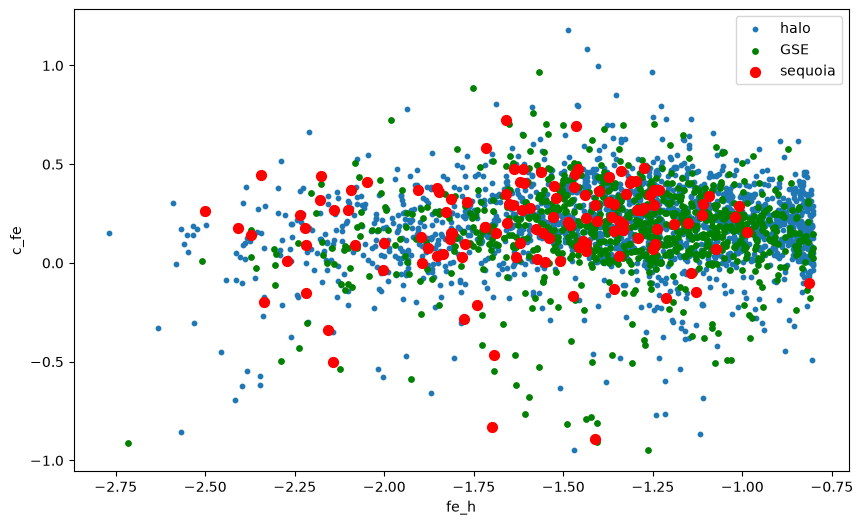

In [156]:
plt.figure(figsize=(10, 6))

elm_2 = 'cu_ca'
elm_1 = 'sc_na'

elm_2 = 'c_fe'
elm_1 = 'fe_h'

# x = Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_1]
# y = Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_2]
# mask = x.notna() & y.notna()
# plt.hist2d(
#     x[mask],
#     y[mask],
#     bins=30,
#     cmap='viridis'
# )
# plt.colorbar(label='count')

plt.scatter(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_1], Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_2], s = 10, alpha = 1, label = 'halo')
plt.scatter(galah_Gaia_GSE_new_ratios_nessessary_flags[elm_1], galah_Gaia_GSE_new_ratios_nessessary_flags[elm_2], s = 15, alpha = 1, label = 'GSE', c = 'g')
plt.scatter(galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_1], galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_2], s = 50, alpha = 1.0, label = 'sequoia', c = 'r')



plt.xlabel(elm_1)
plt.ylabel(elm_2)
plt.legend()

# plt.xlim(-0.1, 0.8)
# plt.ylim(-1, -0.2)

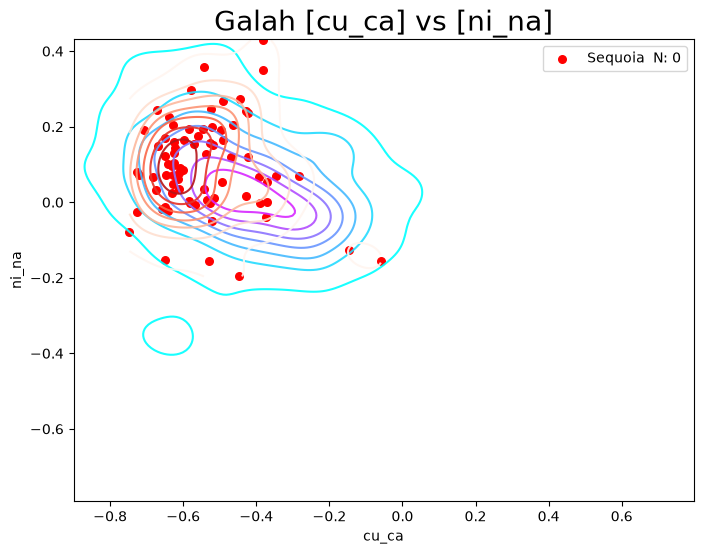

In [ ]:
fig,ax = plt.subplots(figsize=(8, 6))


elm_ratio1 = elm_1 
elm_ratio2 = elm_2
# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )

# plt.scatter(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio1], Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio2],
#             # c = Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
num = len(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags.dropna())
# plt.scatter(-3, -0.5, c = 'aqua', label = f'Halo  N: {num}')
sns.kdeplot(
    # x=(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio1]+ Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio3]).dropna(),
    x= Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio1].dropna(),
    # y =(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio2]+ Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio4]).dropna(),
    y= Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio2].dropna(),
    levels=8,
    cmap='cool',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Halo'
)

# sc = ax.scatter(galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio1], galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios_nessessary_flags['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
# sns.kdeplot(
#     # x=(galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio1]+ galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio3]).dropna(),
#     x= galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio1].dropna(),
#     # y =(galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio2]+ galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio4]).dropna(),
#     y= galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greens',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'GSE'
# )

num = len(galah_Gaia_Sequoia_new_ratios_nessessary_flags.dropna())

ax.scatter(galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio1], galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio2], 
        #    c = galah_Gaia_Sequoia_new_ratios_nessessary_flags['y_fe'], cmap = 'rainbow',
           color = 'red', 
           label = f'Sequoia  N: {num}', s = 30)
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(Sequoia_chem_selected[elm_ratio1], Sequoia_chem_selected[elm_ratio2], label = 'chemically selected "Sequoia" stars', )
# ax.scatter(0.52, -0.8)
# ax.scatter(0.52, -0.5)
# ax.scatter(0.62, -0.8)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

# H_VS_S_X_Low, H_VS_S_X_High = -1.2, None
H_VS_S_X_Low, H_VS_S_X_High = -0.2, None

# H_VS_S_Y_Low, H_VS_S_Y_High = None, None
H_VS_S_Y_Low, H_VS_S_Y_High = -0.6, None


# ax.set_xlim(H_VS_S_X_Low, H_VS_S_X_High)
# ax.set_ylim(H_VS_S_Y_Low, H_VS_S_Y_High)
# ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
# ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)

# ax.set_ylabel(F'[Cr/Sc]', fontsize=20)
# ax.set_xlabel(F'[Ca/V]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])

    ax.set_title(F'Galah [{elm_1}] vs [{elm_2}]', fontsize=20)
    # ax.set_title(F'Galah [Cr/Sc] vs [Ca/V]', fontsize=20)

Means: [-0.40228466]
Standard deviations: [0.08533758]
Weights: [1.]
Maximum PDF value: 4.6748653136701135
Means: [-0.37297545]
Standard deviations: [0.09279498]
Weights: [1.]
Maximum PDF value: 4.2991484908028585
Means: [-0.34755342]
Standard deviations: [0.10878412]
Weights: [1.]
Maximum PDF value: 3.667275616486777


Text(0, 0.5, 'density')

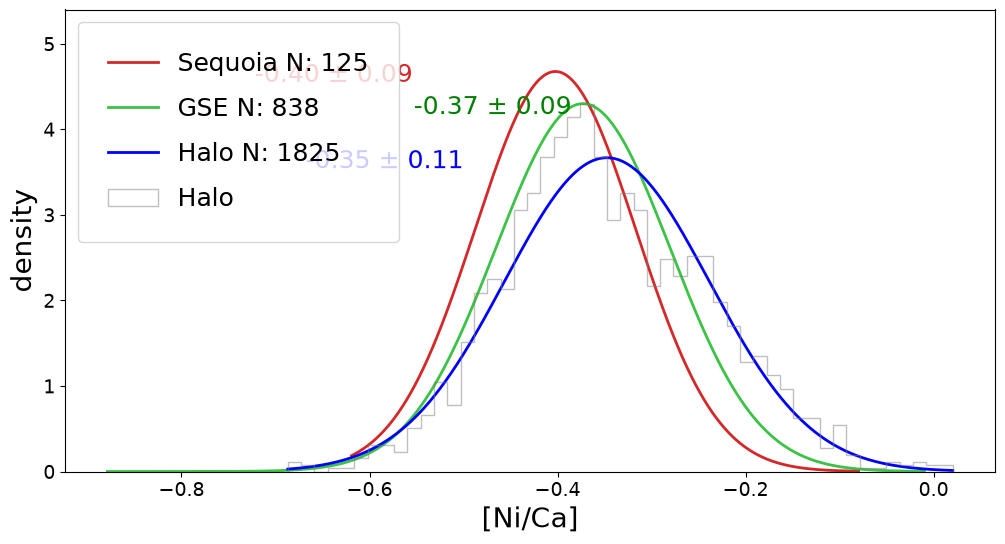

In [150]:
plt.figure(figsize=(12, 6)) #(length, height)
elm_ratio = 'ni_ca'
n_components = 1
shift_right = 0.32
fontsize = 18

elm_lable = elm_ratio
elm_lable_display = '/'.join([seg.capitalize() for seg in elm_lable.replace('_', '/').split('/')])


num = len(galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio].dropna())
plot_gmm(galah_Gaia_Sequoia_new_ratios_nessessary_flags[elm_ratio].dropna(), f'Sequoia N: {num}', n_components = n_components, color=Sequoia_C, maximum_peak=True, plot_compents = True, fontsize = fontsize, 
        #  shift_right=shift_right, shift_up= 0.91)
        shift_right=-0.32, shift_up= 0.0)

num = len(galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio].dropna())
plot_gmm(galah_Gaia_GSE_new_ratios_nessessary_flags[elm_ratio].dropna(), f'GSE N: {num}', n_components = n_components, color=GSE_C, maximum_peak=True, fontsize = fontsize, 
        #  shift_right=shift_right, shift_up= 0.81)
        shift_right=-0.18, shift_up= 0.0)


ti_mask = (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags['ti_fe'] > 0.25)

num = len(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio].dropna())
plot_gmm(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio].dropna(), f'Halo N: {num}', n_components = n_components, color='blue', maximum_peak=True, fontsize = fontsize, shift_right=-0.32, shift_up= 0.0)


# plt.hist(galah_Gaia_Sequoia[elm_ratio].dropna(), bins=30, color = 'r', alpha=0.5, label='Sequoia', density=True, histtype='step')
# plt.hist(galah_Gaia_GSE[elm_ratio].dropna(), bins=30, color = 'g', density=True, histtype='step')
plt.hist(Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags[elm_ratio].dropna(), bins=50, color = 'grey', alpha=0.5, label='Halo', density=True, histtype='step')

# galah_Kushniruk_Thamnos1_mask = (galah_Kushniruk_Thamnos1['fe_h'] <-0.75)
# plt.hist(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), bins=30, color = 'darkseagreen', alpha=0.5, label='Thamnos', density=True, histtype='step')
# plot_gmm(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), f'Halo', n_components = 3, color='darkseagreen', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.61)

leg = plt.legend(fontsize=18, labelspacing=0.8, borderpad=1.2, loc = 'upper left')
# for handle in leg.legend_handles:
    # handle.set_sizes([100])

peak_height  = max(plt.gca().get_ylim())
plt.ylim(0, peak_height * 1.1)
plt.tick_params(axis='x', labelsize=14)
plt.tick_params(axis='y', labelsize=14)
plt.xlabel(f'[{elm_lable_display}]', fontsize = 20)
plt.ylabel('density', fontsize = 20)


In [ ]:
find_ratio_combination_to_try_for_2d_KS_test(galah_Gaia_new_ratios_nessessary_flags_ratio_list, galah_Gaia_GSE_new_ratios_nessessary_flags, galah_Gaia_Halo_new_ratios_nessessary_flags, element_list_nessessary_flags, percent_value = 0.3, keep_num_elm = 6, do_costom_elm_filter = False, costom_elm_filter = [])

percent_value =  0.3
len(ratio_1d_ks_test)  301
len(top_percent)  90
fe and na_fe
fe and ti_fe
fe and ni_fe
fe and y_fe
fe and ca_fe
fe and mg_fe
fe and al_fe
fe and v_fe
fe and si_fe
fe and sm_fe
fe and nd_fe
fe and cu_fe
fe and co_fe
fe and zn_fe
fe and sc_fe
fe and k_fe
fe and o_fe
fe and ba_fe
fe and ce_fe
fe and eu_fe
fe and la_fe
fe and zr_fe
fe and mn_fe
fe and fe_h
fe and cr_fe
o and co_na
o and sm_co
o and nd_co
o and nd_o
o and co_fe
o and la_co
o and la_o
o and y_co
o and sm_o
o and co_al
o and ce_co
o and o_fe
o and al_o
o and co_mn
o and co_ti
o and cr_o
o and na_o
o and eu_o
o and co_o
o and eu_co
o and co_cr
o and ba_o
o and zr_o
o and mn_o
o and ca_o
o and y_o
o and v_o
o and sc_o
o and co_si
o and si_o
o and ce_o
o and zn_co
o and zr_co
o and ti_o
o and k_o
o and cu_o
o and co_v
o and ni_o
o and co_mg
o and mg_o
o and co_sc
o and co_ca
o and ba_co
o and cu_co
o and co_k
o and ni_co
o and zn_o
na and na_fe
na and mn_na
na and nd_na
na and cr_na
na and sm_na
na and ni_na

,element,frequency,score
2,na,19,-446.112907
22,nd,19,-344.490210
0,fe,12,-306.153949
23,sm,18,-304.485255
17,y,14,-276.028905
11,cr,9,-214.867317
9,ti,7,-207.251486
4,al,12,-203.789294
12,mn,9,-179.480461
14,ni,7,-160.666153


auto_elm_filter =  ['na', 'nd', 'fe', 'sm', 'y', 'cr']
79


,ratio,p_value,statistic
2,na_fe,1.544235e-22,0.315030
9,ti_fe,4.716999e-21,0.303328
57,mn_na,1.668671e-17,0.287480
67,nd_na,3.530125e-17,0.302190
277,nd_y,1.849127e-15,0.290380
...,...,...,...
15,cu_fe,1.254698e-04,0.138110
212,ni_cr,1.265030e-04,0.142288
279,eu_y,1.374714e-04,0.253984
103,y_al,1.677527e-04,0.336322


['na_fe',
 'ti_fe',
 'mn_na',
 'nd_na',
 'nd_y',
 'cr_na',
 'cr_ti',
 'ni_fe',
 'sm_na',
 'y_cr',
 'ni_na',
 'y_fe',
 'sm_ti',
 'sm_y',
 'nd_ti',
 'sc_na',
 'sm_ca',
 'ti_na',
 'nd_ni',
 'co_na',
 'nd_zn',
 'ca_fe',
 'nd_k',
 'mg_fe',
 'sm_ni',
 'ca_na',
 'sm_v',
 'sm_si',
 'la_y',
 'mg_na',
 'sm_mg',
 'nd_mg',
 'ba_y',
 'la_na',
 'si_na',
 'sm_co',
 'nd_ca',
 'k_na',
 'nd_ba',
 'y_mn',
 'ba_na',
 'cu_na',
 'nd_sc',
 'sm_cr',
 'nd_cu',
 'nd_al',
 'nd_co',
 'nd_si',
 'nd_v',
 'y_sc',
 'al_fe',
 'sm_zn',
 'nd_mn',
 'v_fe',
 'si_fe',
 'nd_cr',
 'sm_cu',
 'y_si',
 'y_ti',
 'y_ni',
 'sm_sc',
 'v_na',
 'sm_al',
 'eu_na',
 'cr_mg',
 'sm_mn',
 'zn_na',
 'nd_o',
 'sm_ba',
 'sm_k',
 'sm_fe',
 'y_mg',
 'cr_al',
 'nd_fe',
 'cu_fe',
 'ni_cr',
 'eu_y',
 'y_al',
 'cr_ca']

In [181]:
# ratio_list = galah_gaia_new_element_ratio_list
ratio_list = galah_Gaia_new_ratios_nessessary_flags_ratio_list
# ratio_list = ['fe_h']
# ratio_list = one_d_test_test_Halo_vs_Sequoia['ratio'][0:30]
# ratio_list = ['ca_v', 'v_fe', 'ca_fe']


object_list = {
                'Pradosh_Halo': (Halo_Pradosh_galah_Gaia_new_ratios_nessessary_flags,),
                # 'Pradosh_Halo': (Halo_Pradosh_galah_Gaia_new_ratios,),
                # 'GSE': (galah_Gaia_GSE_new_ratios_nessessary_flags,),  #df
                # 'GSE': (galah_Gaia_GSE_new_ratios,),  #df
                'Sequoia': (galah_Gaia_Sequoia_new_ratios_nessessary_flags,),
                # 'Sequoia': (galah_Gaia_Sequoia_new_ratios,),
                # 'Halo': (galah_Gaia_Halo_new_ratios,),
                # 'Pradosh_Halo': (Halo_Pradosh_galah_Gaia_new_ratios,),
                # 'Pradosh_Halo': (Halo_Pradosh_galah_Gaia,),
                # 'ran_1': (random_5000_1_new_ratios,),
                # 'ran_2': (random_5000_2_new_ratios,),
}

# one_d_test_test_Halo_vs_Sequoia = one_d_ks_test(ratio_list, object_list)

# one_d_test_test_GSE_vs_Sequoia = one_d_ks_test(ratio_list, object_list)

one_d_test_test_Halo_vs_GSE = one_d_ks_test(ratio_list, object_list)


In [182]:
one_d_test_test_Halo_vs_GSE[0:50]

,ratio,p_value,statistic,num_samples_1,num_samples_2
0,fe_h,8.968626e-13,0.341694,1834,126
16,cu_fe,1.271476e-11,0.330574,1818,122
175,v_ca,4.427495e-11,0.370766,1502,91
76,k_na,4.761397e-11,0.347716,1619,104
196,cu_sc,4.788048e-09,0.363652,1421,76
180,cu_ca,7.523512e-09,0.359578,1421,76
78,sc_na,1.451055e-08,0.305108,1622,104
77,ca_na,2.706660e-08,0.300044,1623,104
238,cu_cr,3.475643e-08,0.349900,1387,74
163,cu_k,1.875256e-07,0.329022,1418,76


In [ ]:
def one_d_Hyppo_ks_test(ratio_list, object_list):
    (sample1_name, (df1,)), (sample2_name, (df2,)) = object_list.items()

    ratio_ks_test = pd.DataFrame(columns=['ratio', 'p_value', 'statistic', 'num_samples_1', 'num_samples_2'])
    for ratio in ratio_list:
        # plt.figure(figsize=(10, 6))
        # all_values = []


        # for key, (df) in object_list.items():

            # example datasets
        sample1 = df1[ratio].dropna()
        
        sample2 = df2[ratio].dropna()
        
        X = sample1.to_numpy()
        Y = sample2.to_numpy()

        # perform KS test
        statistic, p_value = ks_2samp(sample1, sample2) # Spicy.stats
        # statistic, p_value = KSample('Dcorr').test(X, Y) #Hyppo
        # statistic, p_value = KSample('Hsic').test(X, Y) #Hyppo
        # statistic, p_value = Energy().test(X, Y) #Hyppo


        ratio_ks_test.loc[len(ratio_ks_test)] = [ratio, p_value, statistic, len(sample1), len(sample2)]
        ratio_ks_test = ratio_ks_test.sort_values(
            by='p_value',
            ascending=True
            )
    return ratio_ks_test

In [ ]:
ratio_list = galah_gaia_new_element_ratio_list
# ratio_list = ['fe_h']
# ratio_list = one_d_test_test_Halo_vs_Sequoia['ratio'][0:30]
# ratio_list = ['ca_v', 'v_fe', 'ca_fe']


object_list = {
                'GSE': (galah_Gaia_GSE_new_ratios,),  #df
                # 'Sequoia': (galah_Gaia_Sequoia_new_ratios,),
                # 'Halo': (galah_Gaia_Halo_new_ratios,),
                'Pradosh_Halo': (Halo_Pradosh_galah_Gaia_new_ratios,),
                # 'Pradosh_Halo': (Halo_Pradosh_galah_Gaia,),
                # 'ran_1': (random_5000_1_new_ratios,),
                # 'ran_2': (random_5000_2_new_ratios,),
}

# one_d_test_test_Halo_vs_Sequoia_hyppo = one_d_Hyppo_ks_test(ratio_list, object_list)

# one_d_test_test_GSE_vs_Sequoia = one_d_Hyppo_ks_test(ratio_list, object_list)

one_d_test_test_Halo_vs_GSE_hyppo = one_d_Hyppo_ks_test(ratio_list, object_list)

In [ ]:
display(one_d_test_test_Halo_vs_Sequoia_hyppo) #Ksamp Dcorr

,ratio,p_value,statistic,num_samples_1,num_samples_2
5,ca_v,4.530460e-09,0.027542,65,1147
16,na_sc,6.566144e-08,0.023258,65,1147
34,ca_na,1.292110e-07,0.022177,65,1147
33,k_na,3.329855e-07,0.020667,65,1147
86,cu_ca,4.696796e-07,0.020119,65,1147
...,...,...,...,...,...
49,cr_mg,1.000000e+00,-0.000985,65,1147
107,nd_cr,1.000000e+00,-0.001108,65,1147
69,nd_si,1.000000e+00,-0.001141,65,1147
70,ca_k,1.000000e+00,-0.000836,65,1147


In [ ]:
display(one_d_test_test_Halo_vs_Sequoia_hyppo) # Energy

,ratio,p_value,statistic,num_samples_1,num_samples_2
5,ca_v,4.530460e-09,0.044570,65,1147
16,na_sc,6.566144e-08,0.047752,65,1147
34,ca_na,1.292110e-07,0.052294,65,1147
33,k_na,3.329855e-07,0.050836,65,1147
86,cu_ca,4.696796e-07,0.043503,65,1147
...,...,...,...,...,...
49,cr_mg,1.000000e+00,-0.000866,65,1147
107,nd_cr,1.000000e+00,-0.002332,65,1147
69,nd_si,1.000000e+00,-0.002658,65,1147
70,ca_k,1.000000e+00,-0.001316,65,1147


In [ ]:
display(one_d_test_test_Halo_vs_GSE_hyppo)

,ratio,p_value,statistic,num_samples_1,num_samples_2
37,mn_na,2.258502e-83,0.501667,527,1147
36,cr_na,2.284458e-77,0.484025,527,1147
134,nd_y,1.345137e-65,0.446997,527,1147
44,nd_na,1.409749e-59,0.426586,527,1147
39,ni_na,4.921707e-53,0.403046,527,1147
...,...,...,...,...,...
25,ni_sc,6.879602e-01,0.037028,527,1147
29,ba_sc,6.895964e-01,0.036976,527,1147
54,zn_mg,6.928668e-01,0.036874,527,1147
79,ba_k,7.188885e-01,0.036053,527,1147


In [ ]:
display(one_d_test_test_Halo_vs_GSE_hyppo)

,ratio,p_value,statistic,num_samples_1,num_samples_2
37,mn_na,2.258502e-83,0.501667,527,1147
36,cr_na,2.284458e-77,0.484025,527,1147
134,nd_y,1.345137e-65,0.446997,527,1147
44,nd_na,1.409749e-59,0.426586,527,1147
39,ni_na,4.921707e-53,0.403046,527,1147
...,...,...,...,...,...
25,ni_sc,6.879602e-01,0.037028,527,1147
29,ba_sc,6.895964e-01,0.036976,527,1147
54,zn_mg,6.928668e-01,0.036874,527,1147
79,ba_k,7.188885e-01,0.036053,527,1147


In [ ]:
one_vs_one_vs_one_ratio_list = n_one_vs_one_n(2, galah_gaia_new_element_ratio_list, element_list)

In [ ]:
len(one_vs_one_vs_one_ratio_list)

7140